In [94]:
import os 
os.chdir('D://My_projects//Drug Use//Final Thesis//alcohol')

In [95]:
import pandas as pd
df2=pd.read_csv('W1-4_fulldata_filtered.csv')

In [96]:
df2 = df2[df2['DaysMarijuanaPast12M_W4'].notna()]

In [97]:
df2=df2.drop(columns=['TotalDrinking'],errors='ignore')

In [98]:
df_logit=df2.copy()
keep = {
    "GPA_Index",
    "ParentalWarmth_Index",
    "ParentalSupervision_Index",
    "SportsParticipation_Index"
}

cols_to_drop = [
    col for col in df2.columns
    if "index" in col.lower() and col not in keep
]

df_logit = df_logit.drop(columns=cols_to_drop)


In [99]:
import numpy as np
import pandas as pd

# =========================
# USER SETTINGS
# =========================
target = "DaysMarijuanaPast12M_W4"  
corr_thr = 0.04                      # sensible given weak correlations
pair_corr_cut = 0.80                 # multicollinearity screen

# =========================
# 0) Basic numeric-only frame + drop rows missing target
# =========================
df = df2.copy()

# Keep numeric predictors only (bool allowed)
numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()

if target not in df.columns:
    raise ValueError(f"Target '{target}' not found in df_all.")

# Ensure target is numeric
if not np.issubdtype(df[target].dtype, np.number):
    df[target] = pd.to_numeric(df[target], errors="coerce")

df = df.dropna(subset=[target])

# Candidate predictors
X_cols_all = [c for c in numeric_cols if c != target]

# Drop near-zero variance columns
low_var = [c for c in X_cols_all if df[c].nunique(dropna=True) <= 1]
X_cols_all = [c for c in X_cols_all if c not in low_var]

# =========================
# 1) Filter by correlation with target
# =========================

corrs = df[X_cols_all + [target]].corr(numeric_only=True)[target].drop(target)
corrs_abs = corrs.abs().sort_values(ascending=False)

corr_keep = corrs_abs[corrs_abs >= corr_thr].index.tolist()

# Relax threshold if too few survive
if len(corr_keep) < 10 and len(corrs_abs) > 0:
    corr_thr_relaxed = max(0.01, corr_thr / 2)
    corr_keep = corrs_abs[corrs_abs >= corr_thr_relaxed].index.tolist()
    print(f"[Info] Relaxed corr threshold to {corr_thr_relaxed:.3f}")
else:
    corr_thr_relaxed = corr_thr

print(f"[Step 1] Kept {len(corr_keep)} vars with |corr| ≥ {corr_thr_relaxed:.3f}")

# =========================
# 2) Remove multicollinearity by pairwise correlation
#    (drop weaker-to-target variable)
# =========================
X_corr = df[corr_keep].corr().abs()

to_drop = set()
cols = X_corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if X_corr.loc[c1, c2] >= pair_corr_cut:
            # drop the weaker variable (lower |corr with target|)
            if corrs_abs[c1] >= corrs_abs[c2]:
                to_drop.add(c2)
            else:
                to_drop.add(c1)

pairwise_keep = [c for c in corr_keep if c not in to_drop]

print(f"[Step 2] Dropped {len(to_drop)} vars with pairwise |corr| ≥ {pair_corr_cut:.2f}")
print(f"[Step 2] Remaining vars: {len(pairwise_keep)}")

# =========================
# 3) Outputs
# =========================
vars_decent_corr = corr_keep
vars_low_multicollinearity = pairwise_keep

print("\n=== FINAL FEATURE SET ===")
print(f"Variables kept (n={len(vars_low_multicollinearity)}):")
for v in vars_low_multicollinearity:
    print(v)


# =========================
# 4) Filtered dataframe (NO imputation)
# =========================
df2 = df[vars_low_multicollinearity + [target]].copy()


[Step 1] Kept 70 vars with |corr| ≥ 0.040
[Step 2] Dropped 0 vars with pairwise |corr| ≥ 0.80
[Step 2] Remaining vars: 70

=== FINAL FEATURE SET ===
Variables kept (n=70):
heavy_smoker
DisciplinaryIndex
Trouble_GetAlong_Teachers_W1
SchoolBehavior_Index
Sex_Female
GPA_Index
SexAttitudes_Index
FriendsRespect_Sex
Age_FirstMarijuana
Lifetime_Marijuana
Delinquency_Index
PhysicalFight_W1
SoldDrugs_Z
SchoolTrouble_Index_Z
SawViolentAttack_W1
Support_Index
Fight_Serious_Z
NightAway_W1
Rev_UpsetMother_Sex_Z
ClosenessToMother_W1
WeaponThreat_W1
PeerWeed_Count
NotWorthLiving
Relax_Sex
Age_FirstCocaine
TeacherCare_W1
SES_Index
SchoolExpulsion
FriendCare_W1
DrugsAvailable_Home
LessLonely_Sex
GroupFight_Z
BuildingCondition
DroveWithoutPermission_Z
Age_FirstDrinkNoAdults
ExpectCollege_W1
Bills_Payment_Ability
PeerCig_Count
Age at First Drink
DrinksPerOccasion_Past12mo
StreetCondition
Attractive_Sex
HoursGames_W1
Trouble Paying Attention
Mother_Education
HoursTV_W1
InjuredSomeone
TroubleGetAlong_Stude

## Cutoff 4

In [44]:
df2 = df2[df2["DaysMarijuanaPast12M_W4"].notna()].copy()
df2["heavy_smoker"] = (df2["DaysMarijuanaPast12M_W4"] >4 ).astype(int)

y = df2["heavy_smoker"]

X = df2.drop(columns=["DaysMarijuanaPast12M_W4", "heavy_smoker"])

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [46]:
print("Train class counts:")
print(y_train.value_counts())

print("\nTest class counts:")
print(y_test.value_counts())


Train class counts:
heavy_smoker
0    1351
1     306
Name: count, dtype: int64

Test class counts:
heavy_smoker
0    451
1    102
Name: count, dtype: int64


In [47]:
X_train2=X_train.copy()

In [48]:
X_test2=X_test.copy()

## RandomForest 

Running RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.6342
Best Parameters:
{'n_estimators': 1200, 'min_samples_split': 20, 'min_samples_leaf': 4, 'min_impurity_decrease': 0.0001, 'max_features': 'log2', 'max_depth': 40, 'class_weight': None, 'bootstrap': True}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.1672
Youden J (train OOF): 0.232
Sensitivity (TPR) @ thr: 0.7516
Specificity (TNR) @ thr: 0.4804

RANDOM FOREST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.6751
Test PR–AUC : 0.3267
Threshold used (Youden, from train OOF): 0.1672

Accuracy : 0.5624
Precision: 0.2603
Recall   : 0.7451
F1-score : 0.3858

Confusion Matrix (Test):
 [[235 216]
 [ 26  76]] 

Classification Report (Test):
              precision    recall  f1-score     support
0              0.900383  0.521064  0.660112  451.000000
1              0.260274  0.745098  0.385787  102.000000
accuracy       0.562387  0.562387  0.562387    0

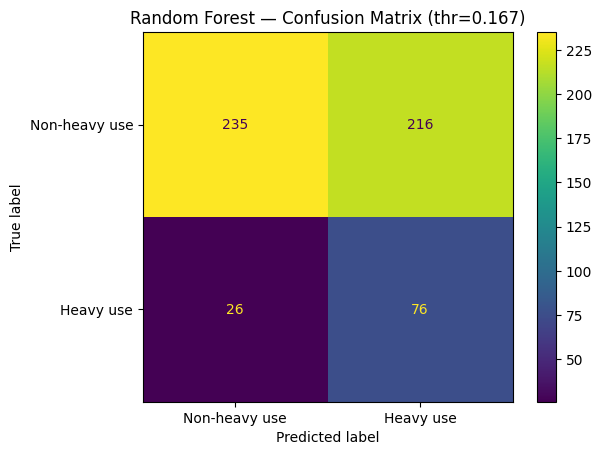

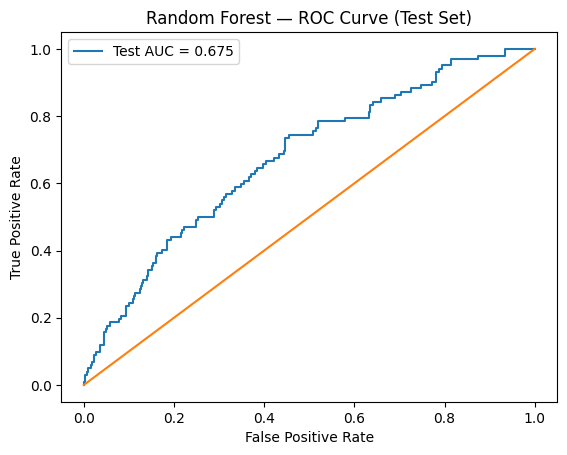

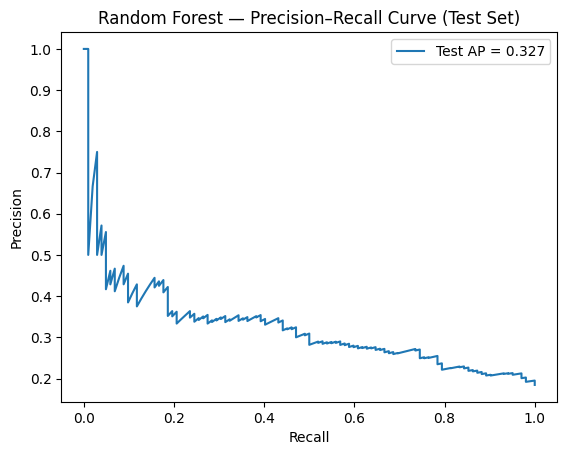

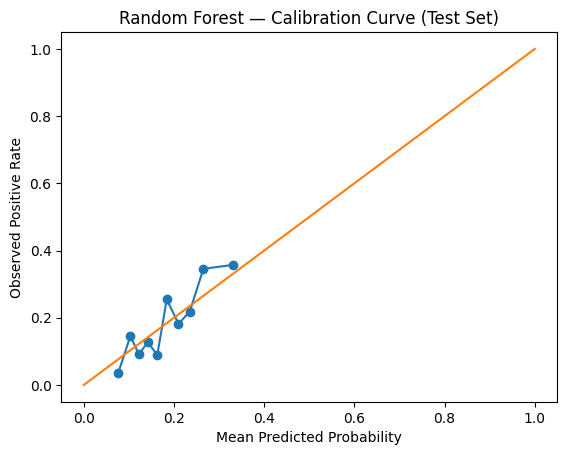

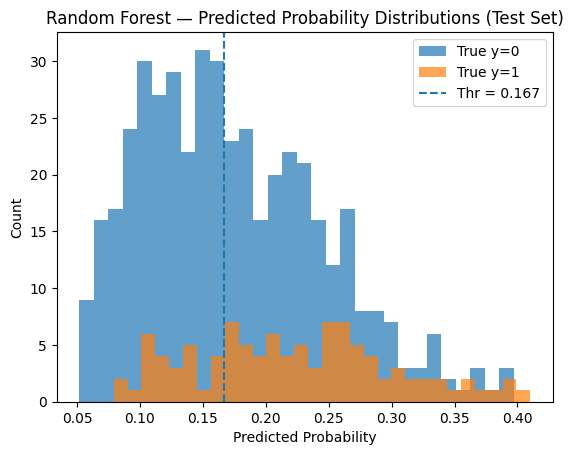


Best RF estimator:
RandomForestClassifier(max_depth=40, max_features='log2',
                       min_impurity_decrease=0.0001, min_samples_leaf=4,
                       min_samples_split=20, n_estimators=1200, n_jobs=-1,
                       random_state=42)


In [49]:
# ============================================================
# RANDOM FOREST — TUNING (CV=3) + YOUDEN (CORRECT: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (COLORED CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 0) SETTINGS
# ----------------------------
RANDOM_STATE = 42

# Tuning CV (your preference)
cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Youden threshold CV (train-only, more stable)
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----------------------------
# 1) BASE MODEL
# ----------------------------
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# ----------------------------
# 2) TUNING SPACE (your grid + a couple of useful additions)
#    Additions:
#    - bootstrap: can affect calibration/variance
#    - min_impurity_decrease: small regularization knob (optional)
# ----------------------------
param_dist = {
    'n_estimators': [300, 500, 800, 1200, 1600],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6, 10],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.8, None],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'bootstrap': [True, False],
    'min_impurity_decrease': [0.0, 0.0001, 0.001]
}

rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running RandomizedSearchCV...")
rs.fit(X_train2, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs.best_score_, 4))
print("Best Parameters:")
print(rs.best_params_)

best_rf = rs.best_estimator_  # best hyperparameters (refit=True by default)

# ----------------------------
# 3) YOUDEN THRESHOLD (CORRECT WAY)
#    - compute OOF probabilities on TRAIN ONLY using CV=5
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

oof_prob = cross_val_predict(
    best_rf,
    X_train2, y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_thr, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_thr, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))

# ----------------------------
# 4) FINAL MODEL FIT ON FULL TRAIN + SINGLE TEST EVALUATION
# ----------------------------
best_rf.fit(X_train2, y_train)

y_prob_test = best_rf.predict_proba(X_test2)[:, 1]
y_pred_test = (y_prob_test >= youden_thr).astype(int)

test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("RANDOM FOREST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {test_auc:.4f}")
print(f"Test PR–AUC : {test_ap:.4f}")
print(f"Threshold used (Youden, from train OOF): {youden_thr:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)

# Summary table (handy for thesis)
summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs.best_score_,
        youden_thr,
        youden_j_best,
        test_auc,
        test_ap,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(summary)

# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 COLORED CONFUSION MATRIX (Matplotlib colormap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"Random Forest — Confusion Matrix (thr={youden_thr:.3f})")
plt.show()

# 5.2 ROC CURVE (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 PRECISION–RECALL CURVE (TEST)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"Test AP = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 CALIBRATION CURVE (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Random Forest — Calibration Curve (Test Set)")
plt.show()

# 5.5 PROBABILITY DISTRIBUTIONS (TEST) + THRESHOLD
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(youden_thr, linestyle="--", label=f"Thr = {youden_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Random Forest — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

print("\nBest RF estimator:")
print(best_rf)


## Catboost

Running CatBoost RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.6314
Best Parameters (CatBoost):
{'subsample': 0.9, 'rsm': 0.6, 'random_strength': 10, 'learning_rate': 0.01, 'l2_leaf_reg': 7, 'iterations': 400, 'depth': 4, 'class_weights': [1, 5], 'bagging_temperature': 0}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.503
Youden J (train OOF): 0.2407
Sensitivity (TPR) @ thr: 0.6634
Specificity (TNR) @ thr: 0.5774

CATBOOST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.6786
Test PR–AUC : 0.3472
Threshold used (Youden, from train OOF): 0.5030

Accuracy : 0.6112
Precision: 0.2656
Recall   : 0.6275
F1-score : 0.3732

Confusion Matrix (Test):
 [[274 177]
 [ 38  64]] 

Classification Report (Test):
              precision    recall  f1-score     support
0              0.878205  0.607539  0.718218  451.000000
1              0.265560  0.627451  0.373178  102.000000
accuracy       0.611212  0.611212  0.61121

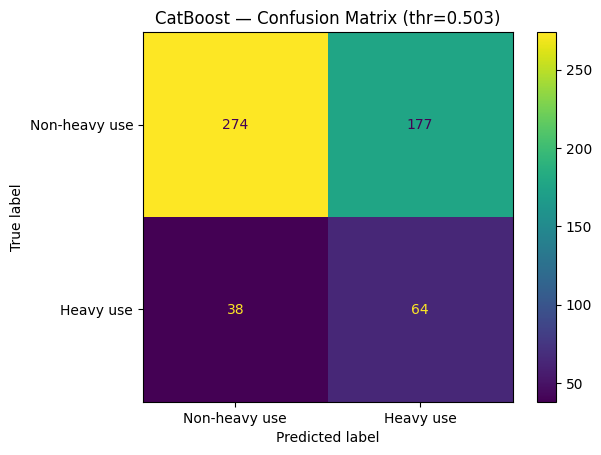

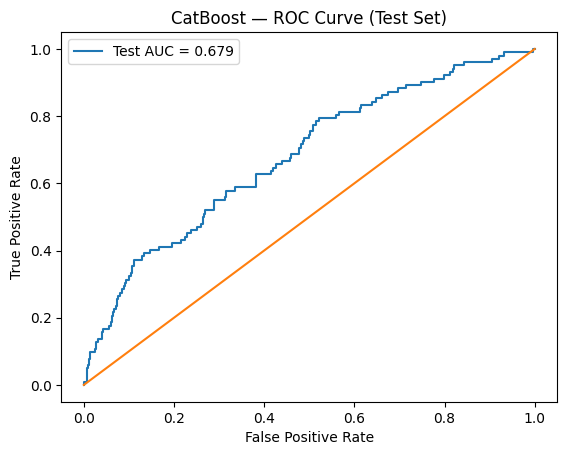

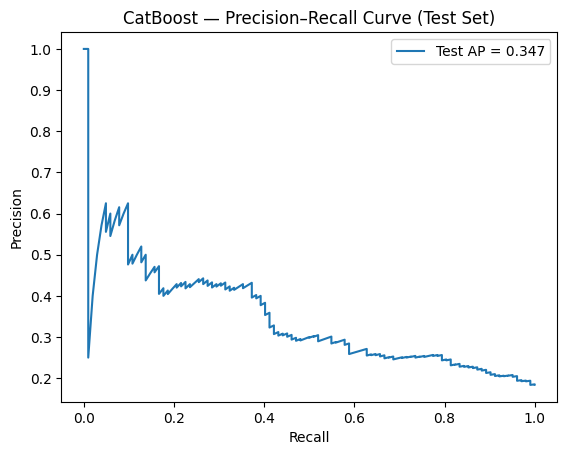

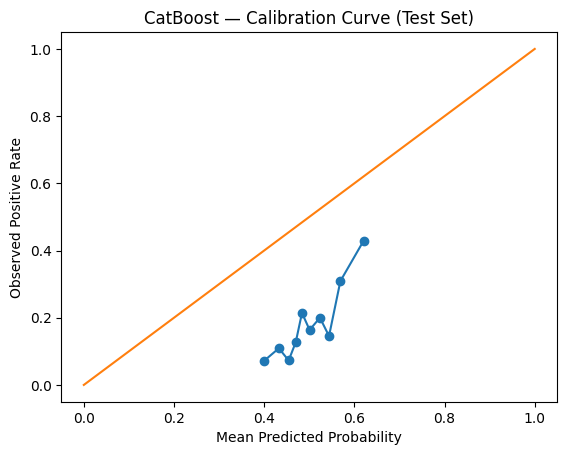

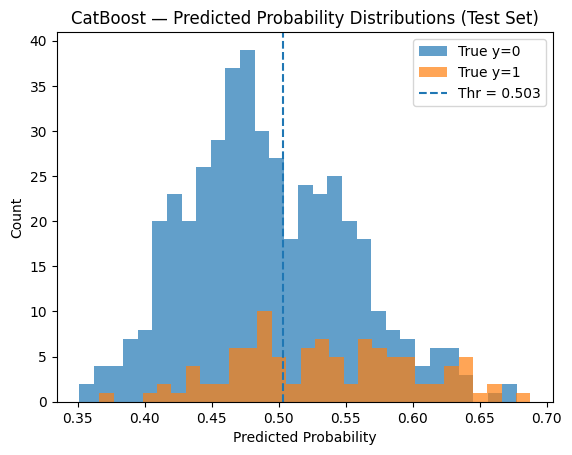


Best CatBoost estimator:


In [50]:
# ============================================================
# CATBOOST — TUNING (CV=3) + YOUDEN (CORRECT: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (COLORED CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 0) SETTINGS
# ----------------------------
RANDOM_STATE = 42

cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # tuning CV
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) # threshold CV

# ----------------------------
# 1) BASE MODEL
# ----------------------------
cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)

# ----------------------------
# 2) TUNING SPACE
#    Your grid + a couple of useful additions for generalization:
#    - rsm (feature subsampling) helps reduce overfit
#    - bagging_temperature controls bootstrap strength (esp. good for CatBoost)
# ----------------------------
param_dist_cat = {
    "iterations": [400, 800, 1200, 1600],
    "depth": [4, 5, 6, 7, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9, 12, 15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "random_strength": [0, 1, 2, 5, 10],
    "bagging_temperature": [0, 1, 5, 10],
    "rsm": [0.6, 0.8, 1.0],
    # your class-weights tuning (fine)
    "class_weights": [[1, 3], [1, 5], [1, 7], [1, 10]]
}

rs_cat = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist_cat,
    n_iter=40,
    scoring="roc_auc",
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running CatBoost RandomizedSearchCV...")
rs_cat.fit(X_train2, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs_cat.best_score_, 4))
print("Best Parameters (CatBoost):")
print(rs_cat.best_params_)

best_cat = rs_cat.best_estimator_  # refit=True by default


# ----------------------------
# 3) YOUDEN THRESHOLD (CORRECT WAY): TRAIN ONLY, CV=5 OOF PROBS
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

oof_prob = cross_val_predict(
    best_cat,
    X_train2, y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_thr, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_thr, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))


# ----------------------------
# 4) FINAL MODEL FIT ON FULL TRAIN + SINGLE TEST EVALUATION
# ----------------------------
best_cat.fit(X_train2, y_train)

y_prob_test = best_cat.predict_proba(X_test2)[:, 1]
y_pred_test = (y_prob_test >= youden_thr).astype(int)

test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("CATBOOST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {test_auc:.4f}")
print(f"Test PR–AUC : {test_ap:.4f}")
print(f"Threshold used (Youden, from train OOF): {youden_thr:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)

# Summary table (handy for thesis)
summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs_cat.best_score_,
        youden_thr,
        youden_j_best,
        test_auc,
        test_ap,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(summary)


# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 COLORED CONFUSION MATRIX (Matplotlib colormap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"CatBoost — Confusion Matrix (thr={youden_thr:.3f})")
plt.show()

# 5.2 ROC CURVE (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CatBoost — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 PRECISION–RECALL CURVE (TEST)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"Test AP = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CatBoost — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 CALIBRATION CURVE (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("CatBoost — Calibration Curve (Test Set)")
plt.show()

# 5.5 PROBABILITY DISTRIBUTIONS (TEST) + THRESHOLD
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(youden_thr, linestyle="--", label=f"Thr = {youden_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("CatBoost — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

print("\nBest CatBoost estimator:")
print(best_cat)


In [51]:
from catboost import CatBoostClassifier

# Re-create best model from your RandomizedSearchCV results
best_cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,

    subsample=0.9,
    rsm=0.6,
    random_strength=10,
    learning_rate=0.01,
    l2_leaf_reg=7,
    iterations=400,
    depth=4,
    class_weights=[1, 5],
    bagging_temperature=0
)

# Train on full training set
best_cat.fit(X_train2, y_train)

print(" Best CatBoost model trained on full training data.")
print(best_cat)


 Best CatBoost model trained on full training data.


In [52]:
from sklearn.metrics import roc_auc_score
X_test2=X_test.copy()
# Predicted probabilities for class 1
y_prob_test = best_cat.predict_proba(X_test2)[:, 1]

# Test ROC–AUC
test_auc = roc_auc_score(y_test, y_prob_test)

print(f"CatBoost Test ROC–AUC (Marijuana, cutoff=4): {test_auc:.4f}")


CatBoost Test ROC–AUC (Marijuana, cutoff=4): 0.6786


X_bg dtype: [dtype('float32')]
X_test dtype: [dtype('float32')]


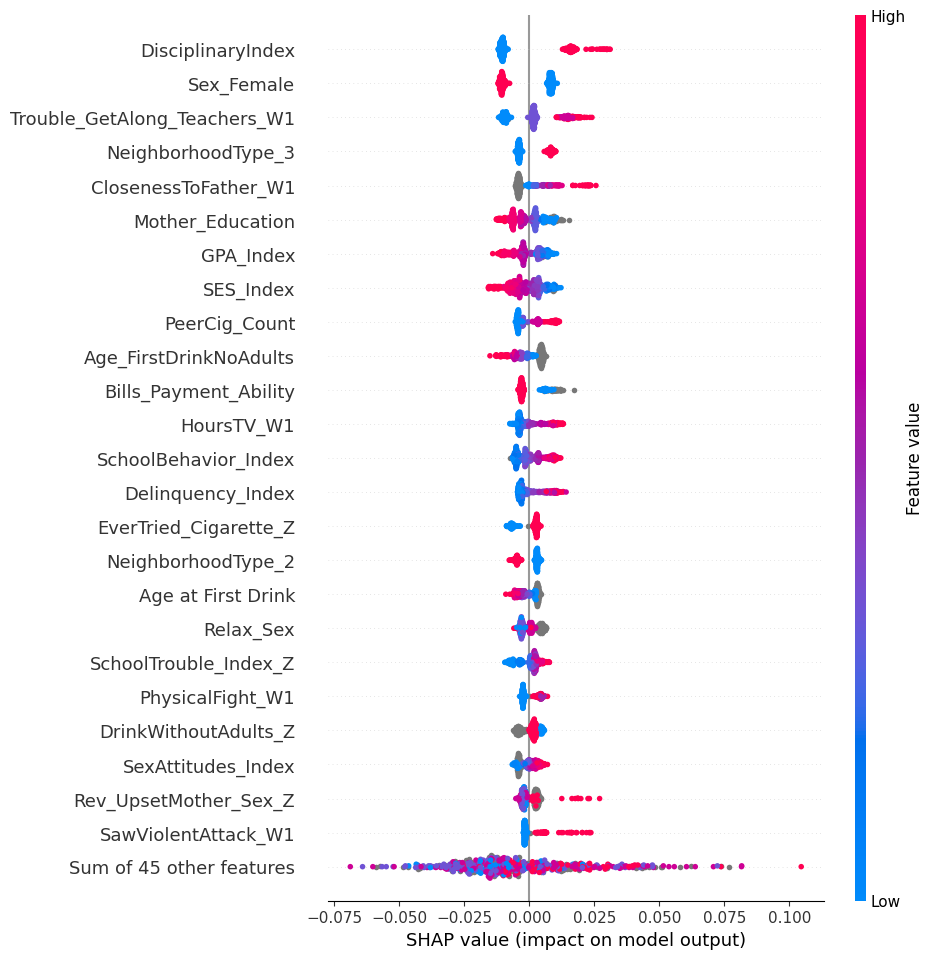

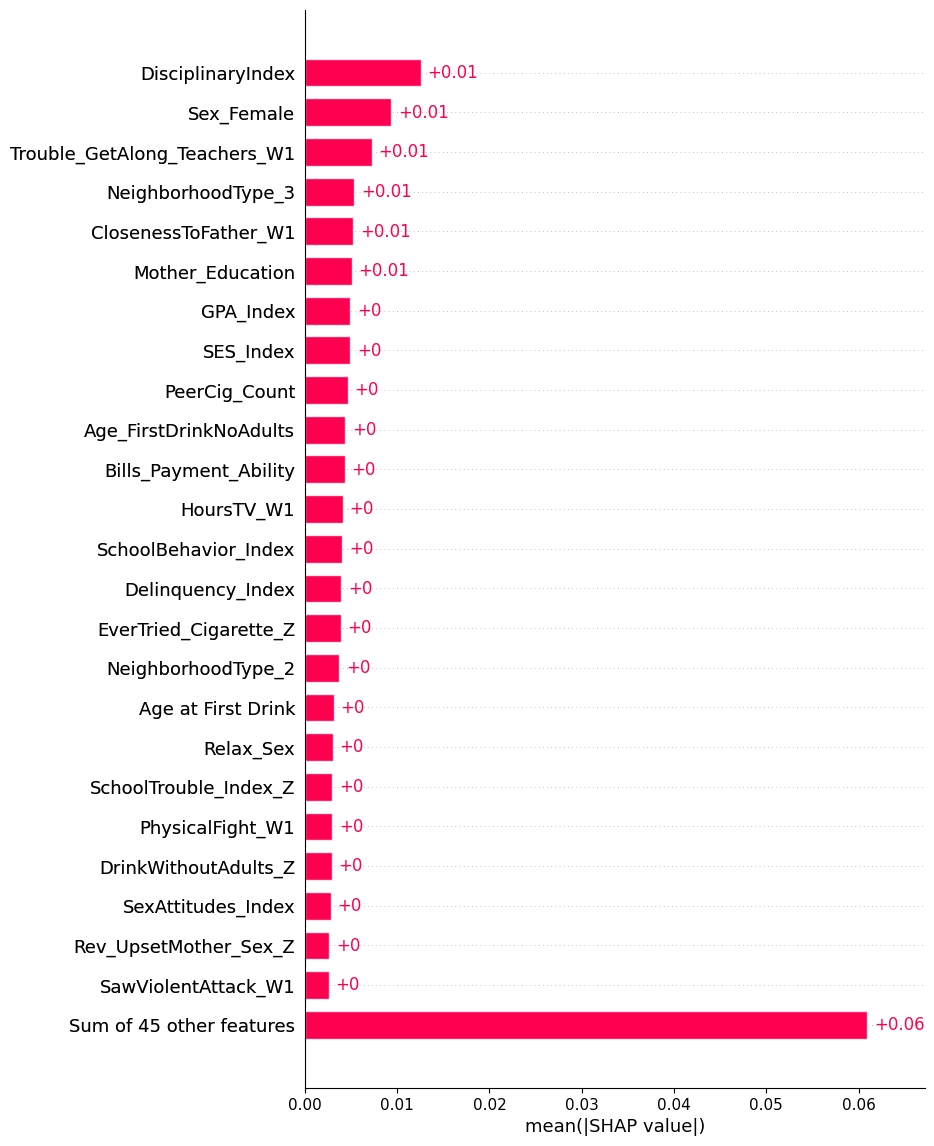

Top SHAP features: ['DisciplinaryIndex', 'Sex_Female', 'Trouble_GetAlong_Teachers_W1', 'NeighborhoodType_3', 'ClosenessToFather_W1', 'Mother_Education', 'GPA_Index', 'SES_Index', 'PeerCig_Count', 'Age_FirstDrinkNoAdults']


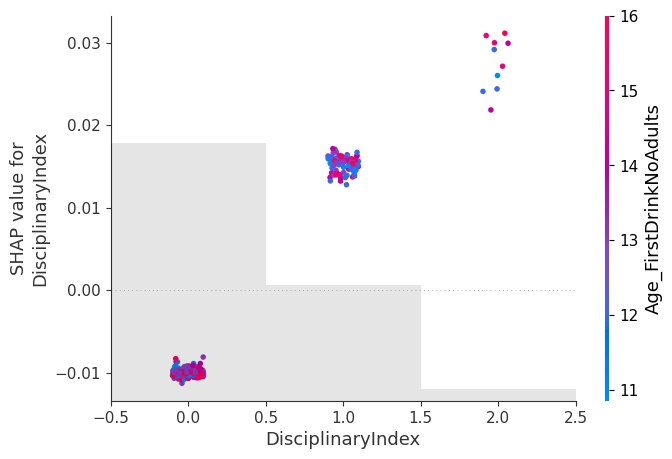

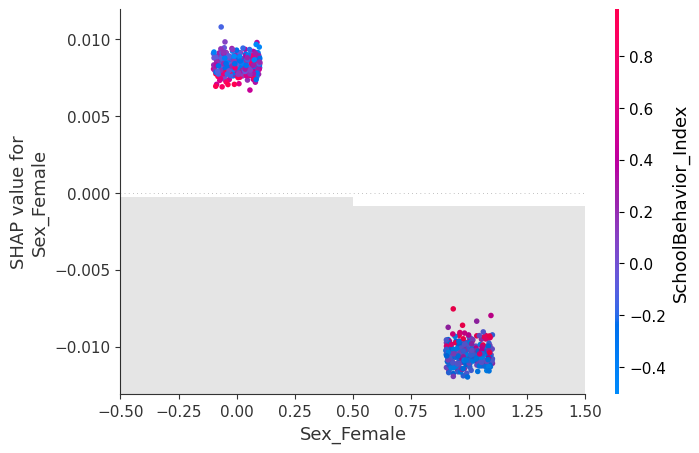

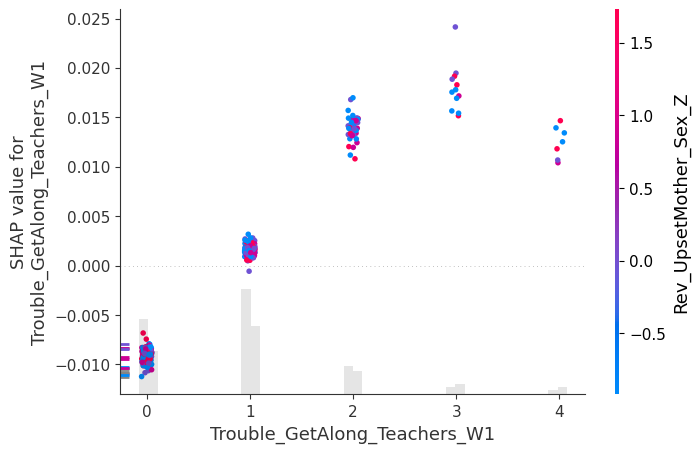

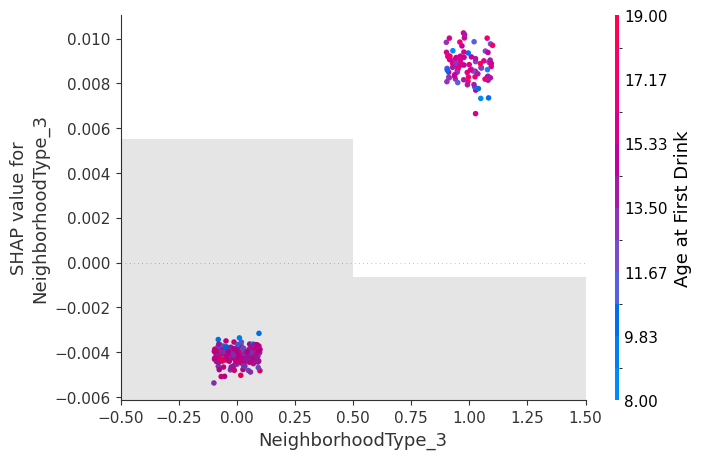

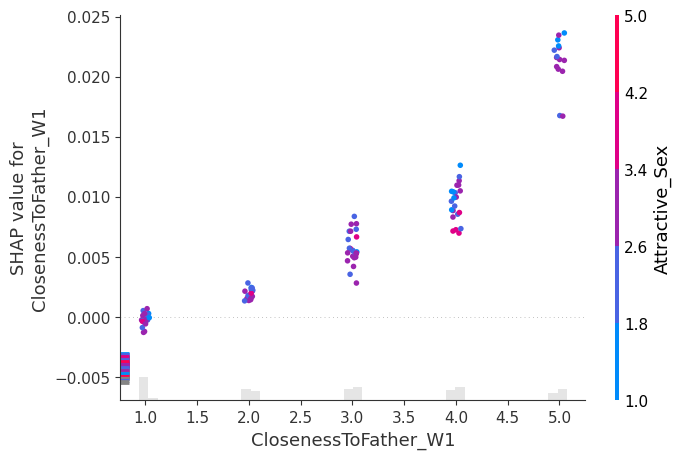

Explaining test row index: 388


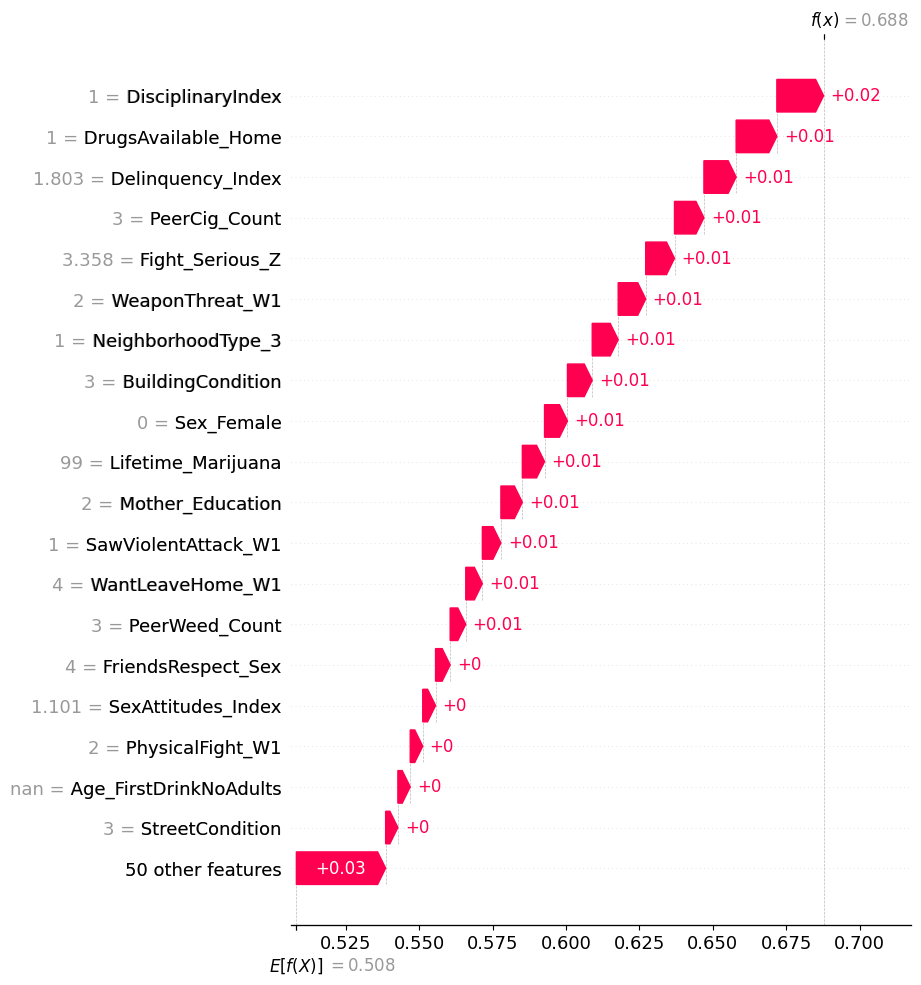

In [53]:
# ============================
# SHAP analysis for best_cat (CatBoost)
# ============================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) Make sure X_* are DataFrames (keeps feature names)
X_train_cb = X_train2.copy()
X_test_cb  = X_test2.copy()

if not isinstance(X_train_cb, pd.DataFrame):
    X_train_cb = pd.DataFrame(X_train_cb)
if not isinstance(X_test_cb, pd.DataFrame):
    X_test_cb = pd.DataFrame(X_test_cb)

feature_names = X_train_cb.columns.tolist()

# 1) Optional: clean dtypes (bool -> int, everything numeric)
def force_numeric(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    bool_cols = df.select_dtypes(include=["bool"]).columns
    df[bool_cols] = df[bool_cols].astype(np.int8)

    # If anything is object, try coercing to numeric (will raise if truly non-numeric)
    obj_cols = df.select_dtypes(include=["object"]).columns
    if len(obj_cols) > 0:
        df[obj_cols] = df[obj_cols].apply(pd.to_numeric, errors="raise")

    return df.astype(np.float32)

X_train_shap = force_numeric(X_train_cb)
X_test_shap  = force_numeric(X_test_cb)

# 2) Background sample (recommended for speed)
bg_size = min(200, len(X_train_shap))
X_bg = X_train_shap.sample(bg_size, random_state=42)

print("X_bg dtype:", X_bg.dtypes.unique())
print("X_test dtype:", X_test_shap.dtypes.unique())

# 3) SHAP explainer (TreeExplainer is ideal for CatBoost)
#    model_output="probability" makes SHAP values correspond to predicted probability (class 1).
explainer = shap.TreeExplainer(best_cat, data=X_bg, model_output="probability")
shap_values = explainer(X_test_shap)  # returns Explanation

# 4) Global: beeswarm + bar
shap.plots.beeswarm(shap_values, max_display=25)
shap.plots.bar(shap_values, max_display=25)

# ---------------------------------------------------------
# B) DEPENDENCE: top features (scatter plots)
# ---------------------------------------------------------
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:10]
top_features = X_test_shap.columns[top_idx].tolist()

print("Top SHAP features:", top_features)

for feat in top_features[:5]:
    shap.plots.scatter(shap_values[:, feat], color=shap_values)

# ---------------------------------------------------------
# C) LOCAL: explain a single prediction
# ---------------------------------------------------------
# Choose instance = highest predicted risk (class 1 prob)
idx = int(np.argmax(best_cat.predict_proba(X_test_cb)[:, 1]))
print("Explaining test row index:", idx)

shap.plots.waterfall(shap_values[idx], max_display=20)

# Force plot (interactive in notebooks)
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values.values[idx, :],
    X_test_cb.iloc[idx, :],
)

# ---------------------------------------------------------
# D) (Optional) SHAP values table export
# ---------------------------------------------------------
shap_df = pd.DataFrame(shap_values.values, columns=feature_names)
shap_df["pred_prob"] = best_cat.predict_proba(X_test_cb)[:, 1]
shap_df["y_true"] = np.asarray(y_test)

# shap_df.to_csv("shap_values_test_catboost.csv", index=False)


In [54]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ----------------------------
# 0) Inputs you already have
# ----------------------------
# shap_values: shap.Explanation from explainer(X_test_shap)
# shap_df: DataFrame with shap values + pred_prob + y_true
# X_test_cb: original test features (DataFrame)
# y_test: true labels

# Ensure alignment (very important)
X_profile = X_test_cb.reset_index(drop=True).copy()
shap_only = pd.DataFrame(shap_values.values, columns=feature_names).reset_index(drop=True)

pred_prob = shap_df["pred_prob"].reset_index(drop=True)
y_true    = shap_df["y_true"].reset_index(drop=True)

assert len(X_profile) == len(shap_only) == len(pred_prob) == len(y_true)

# ----------------------------
# 1) Choose SHAP feature space (top m features)
#    (use top features by mean |SHAP| for stability/interpretability)
# ----------------------------
m = 20  # you can set 15–30; 20 is a good default
mean_abs = np.abs(shap_only.values).mean(axis=0)
top_m_idx = np.argsort(mean_abs)[::-1][:m]
top_m_features = shap_only.columns[top_m_idx].tolist()

print("Top SHAP features used for archetypes:", top_m_features)

S = shap_only[top_m_features].copy()

# Standardize SHAP space (recommended for clustering)
scaler = StandardScaler()
S_scaled = scaler.fit_transform(S)

# ----------------------------
# 2) Pick number of archetypes (K) using silhouette
# ----------------------------
k_candidates = range(2, 9)  # try 2..8
sil = {}

for k in k_candidates:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = km.fit_predict(S_scaled)
    sil[k] = silhouette_score(S_scaled, labels_k)

best_k = max(sil, key=sil.get)
print("Silhouette by K:", sil)
print("Selected K:", best_k)

# ----------------------------
# 3) Fit final clustering model
# ----------------------------
km = KMeans(n_clusters=best_k, random_state=42, n_init=50)
cluster = km.fit_predict(S_scaled)

# Attach cluster labels
arch = pd.DataFrame({
    "cluster": cluster,
    "pred_prob": pred_prob,
    "y_true": y_true
})

arch["cluster"] = arch["cluster"].astype(int)


Top SHAP features used for archetypes: ['DisciplinaryIndex', 'Sex_Female', 'Trouble_GetAlong_Teachers_W1', 'NeighborhoodType_3', 'ClosenessToFather_W1', 'Mother_Education', 'GPA_Index', 'SES_Index', 'PeerCig_Count', 'Age_FirstDrinkNoAdults', 'Bills_Payment_Ability', 'HoursTV_W1', 'SchoolBehavior_Index', 'Delinquency_Index', 'EverTried_Cigarette_Z', 'NeighborhoodType_2', 'Age at First Drink', 'Relax_Sex', 'SchoolTrouble_Index_Z', 'PhysicalFight_W1']
Silhouette by K: {2: 0.11714551791203029, 3: 0.09363121385497512, 4: 0.08821912304124181, 5: 0.08715297115612414, 6: 0.08102558225463706, 7: 0.07710817335667051, 8: 0.07813040531774032}
Selected K: 2


In [55]:
summary_arch = (
    arch.groupby("cluster")
        .agg(
            n=("y_true", "size"),
            heavy_rate=("y_true", "mean"),
            mean_pred_prob=("pred_prob", "mean"),
            median_pred_prob=("pred_prob", "median")
        )
        .sort_values("mean_pred_prob", ascending=False)
)

summary_arch["heavy_rate"] = summary_arch["heavy_rate"].round(3)
summary_arch["mean_pred_prob"] = summary_arch["mean_pred_prob"].round(3)
summary_arch["median_pred_prob"] = summary_arch["median_pred_prob"].round(3)

print(summary_arch)


           n  heavy_rate  mean_pred_prob  median_pred_prob
cluster                                                   
0        216       0.255           0.560             0.556
1        337       0.139           0.461             0.465


In [56]:
# Mean SHAP per cluster (top features only)
S_with_cluster = S.copy()
S_with_cluster["cluster"] = cluster

mean_shap_cluster = S_with_cluster.groupby("cluster").mean()

# For each cluster, show top drivers by absolute mean SHAP
top_drivers = {}
for c in mean_shap_cluster.index:
    s = mean_shap_cluster.loc[c]
    top = s.reindex(s.abs().sort_values(ascending=False).index).head(10)
    top_drivers[c] = top

for c, top in top_drivers.items():
    print("\n======================================")
    print(f"Cluster {c} — Top SHAP drivers (mean SHAP, probability scale)")
    print("======================================")
    print(top.round(4))



Cluster 0 — Top SHAP drivers (mean SHAP, probability scale)
DisciplinaryIndex               0.0104
Trouble_GetAlong_Teachers_W1    0.0050
SchoolBehavior_Index            0.0041
Delinquency_Index               0.0029
GPA_Index                       0.0021
Sex_Female                      0.0020
SchoolTrouble_Index_Z           0.0018
PhysicalFight_W1                0.0014
PeerCig_Count                   0.0014
Bills_Payment_Ability           0.0012
Name: 0, dtype: float64

Cluster 1 — Top SHAP drivers (mean SHAP, probability scale)
DisciplinaryIndex              -0.0089
SchoolBehavior_Index           -0.0031
Sex_Female                     -0.0027
SES_Index                      -0.0024
Delinquency_Index              -0.0023
GPA_Index                      -0.0020
PeerCig_Count                  -0.0019
Trouble_GetAlong_Teachers_W1   -0.0018
Mother_Education               -0.0015
ClosenessToFather_W1           -0.0014
Name: 1, dtype: float64


In [57]:
# Detect binary columns (0/1)
binary_cols = [c for c in X_profile.columns
               if set(pd.Series(X_profile[c]).dropna().unique()).issubset({0, 1})]

# Numeric cols (everything else)
numeric_cols = [c for c in X_profile.columns if c not in binary_cols]

X_with_cluster = X_profile.copy()
X_with_cluster["cluster"] = cluster

# 1) Binary profile: mean = % with value 1
bin_profile = X_with_cluster.groupby("cluster")[binary_cols].mean()

# 2) Numeric profile: mean values
num_profile = X_with_cluster.groupby("cluster")[numeric_cols].mean(numeric_only=True)

# Show a compact profile for each cluster:
# - top 10 binary differences (highest %1)
# - top 10 numeric (highest mean)
for c in sorted(X_with_cluster["cluster"].unique()):
    print("\n=================================================")
    print(f"Cluster {c} — Feature-value profile (raw X)")
    print("=================================================")

    if len(binary_cols) > 0:
        print("\nBinary (% = mean of 0/1):")
        print(bin_profile.loc[c].sort_values(ascending=False).head(10).round(3))

    print("\nNumeric (means):")
    # show only numeric among the top SHAP features if present
    numeric_in_top = [f for f in top_m_features if f in num_profile.columns]
    if len(numeric_in_top) > 0:
        print(num_profile.loc[c, numeric_in_top].sort_values(ascending=False).round(3))
    else:
        print(num_profile.loc[c].sort_values(ascending=False).head(10).round(3))



Cluster 0 — Feature-value profile (raw X)

Binary (% = mean of 0/1):
Bills_Payment_Ability    0.742
WorkedForPay_W1          0.574
NeighborhoodType_2       0.407
Sex_Female               0.338
NightAway_W1             0.315
HouseholdSmokes          0.310
NeighborhoodType_3       0.287
SuicidalIdeation         0.219
SchoolExpulsion          0.098
DrugsAvailable_Home      0.060
Name: 0, dtype: float64

Numeric (means):
HoursTV_W1                      16.926
Age at First Drink              13.992
Age_FirstDrinkNoAdults          13.195
Mother_Education                 5.332
Relax_Sex                        3.369
ClosenessToFather_W1             2.942
GPA_Index                        2.409
Trouble_GetAlong_Teachers_W1     1.481
PeerCig_Count                    1.455
PhysicalFight_W1                 0.894
DisciplinaryIndex                0.833
SchoolTrouble_Index_Z            0.714
Delinquency_Index                0.550
EverTried_Cigarette_Z            0.496
SchoolBehavior_Index            

Prototype row index per cluster: {0: 513, 1: 536}

--- Archetype 0: prototype index 513 ---


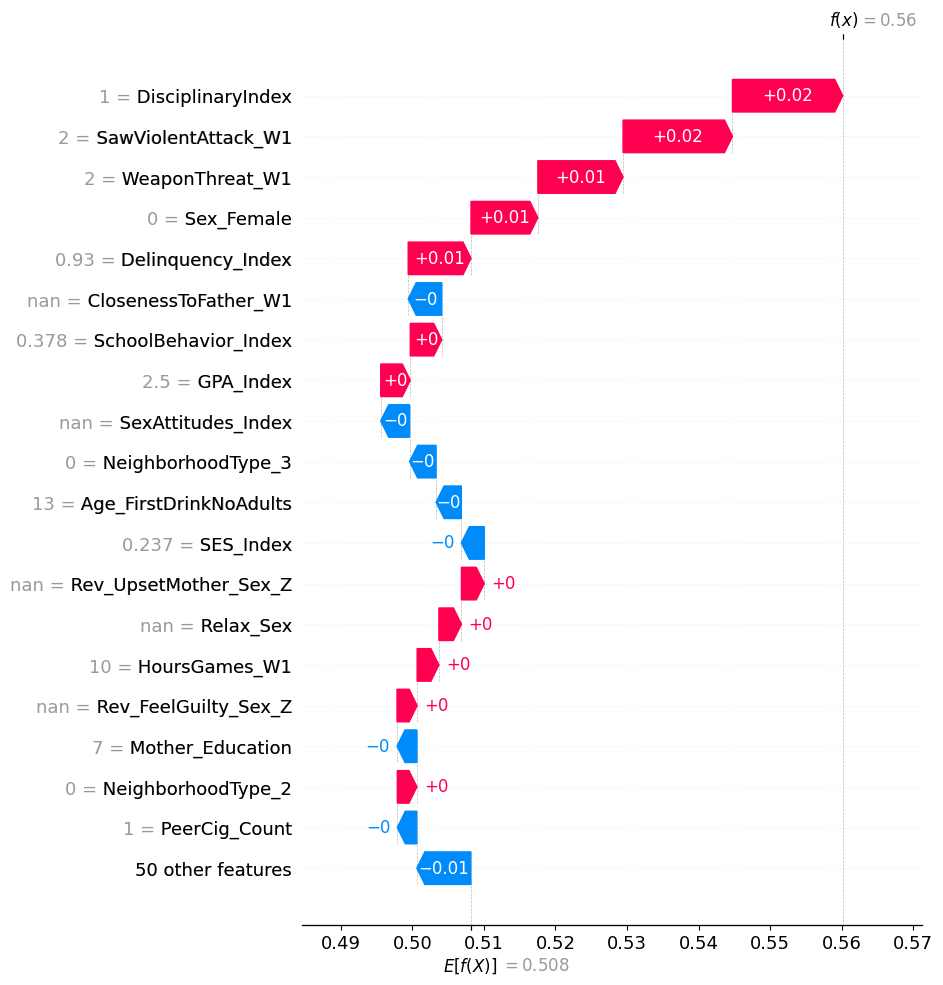


--- Archetype 1: prototype index 536 ---


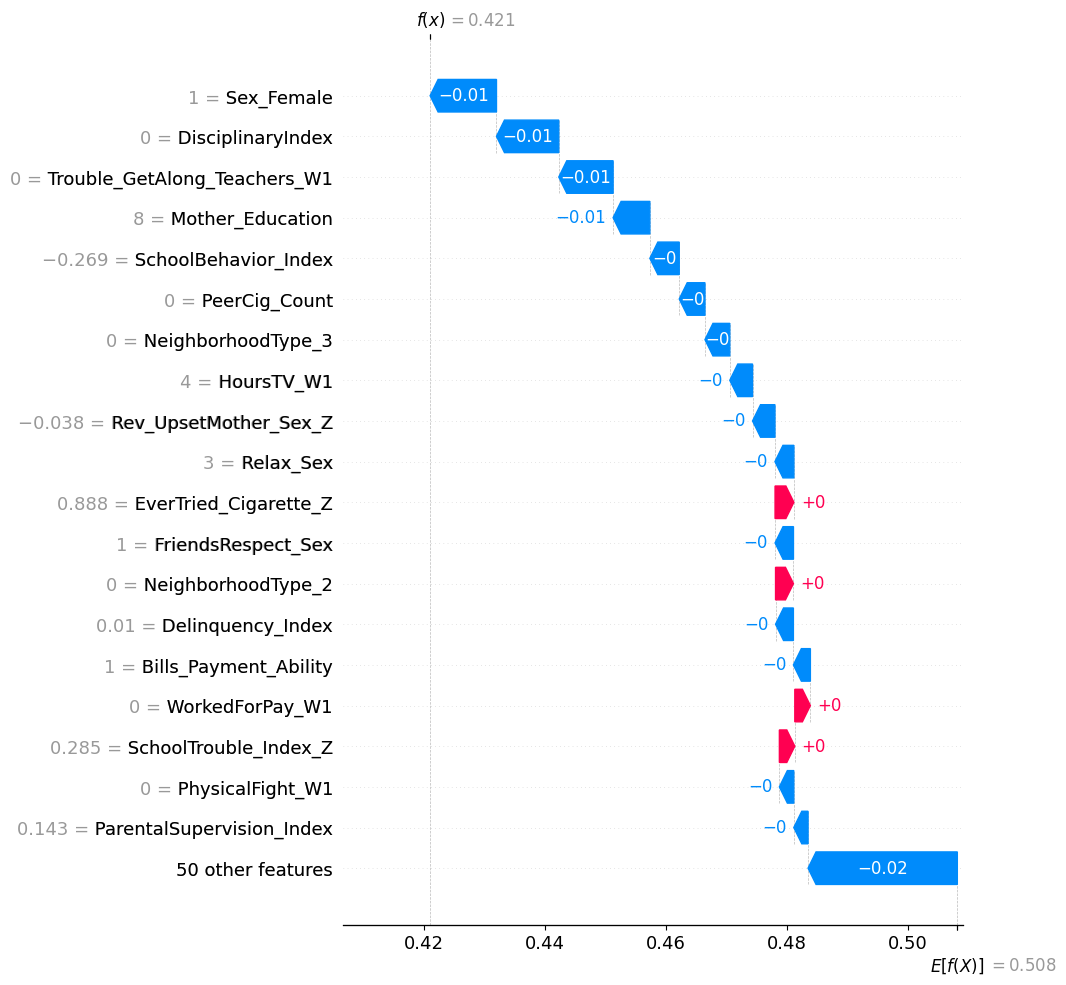

In [58]:
# Find prototype index (closest to centroid in SHAP space)
centroids = km.cluster_centers_
prototypes = {}

for c in range(best_k):
    idxs = np.where(cluster == c)[0]
    # distance to centroid in scaled SHAP space
    d = np.linalg.norm(S_scaled[idxs] - centroids[c], axis=1)
    proto_idx = idxs[np.argmin(d)]
    prototypes[c] = int(proto_idx)

print("Prototype row index per cluster:", prototypes)

# Example: show SHAP waterfall for each prototype
import shap
for c, proto_idx in prototypes.items():
    print(f"\n--- Archetype {c}: prototype index {proto_idx} ---")
    shap.plots.waterfall(shap_values[proto_idx], max_display=20)


## XGBoost

Running XGBoost RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.6191
Best Parameters (XGBoost):
{'subsample': 0.9, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 12, 'max_depth': 3, 'max_delta_step': 1, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.4523
Youden J (train OOF): 0.2204
Sensitivity (TPR) @ thr: 0.683
Specificity (TNR) @ thr: 0.5374

XGBOOST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.6553
Test PR–AUC : 0.3183
Threshold used (Youden, from train OOF): 0.4523

Accuracy : 0.5859
Precision: 0.2567
Recall   : 0.6569
F1-score : 0.3691

Confusion Matrix (Test):
 [[257 194]
 [ 35  67]] 

Classification Report (Test):
              precision    recall  f1-score     support
0              0.880137  0.569845  0.691790  451.000000
1              0.256705  0.656863  0.369146  102.000000
accuracy       0.585895  0.

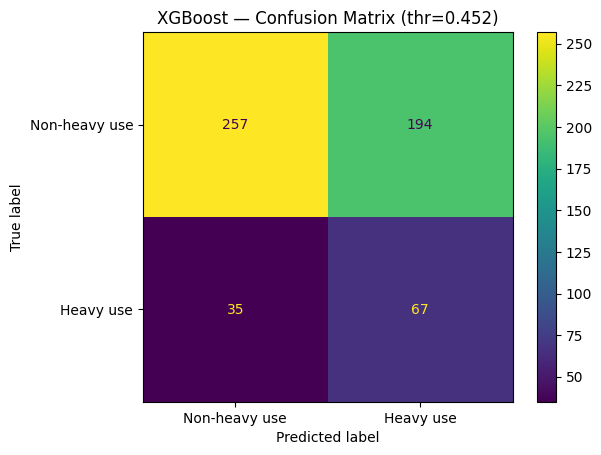

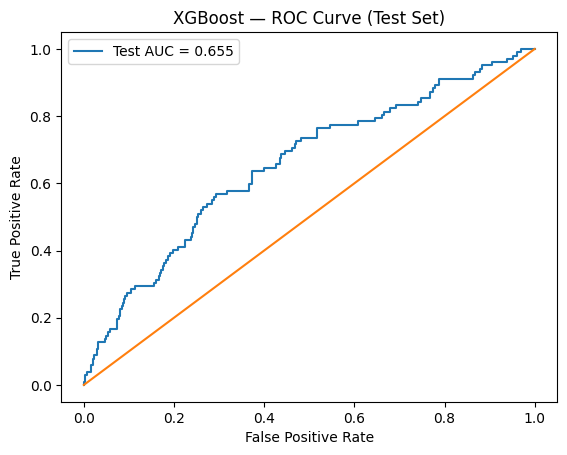

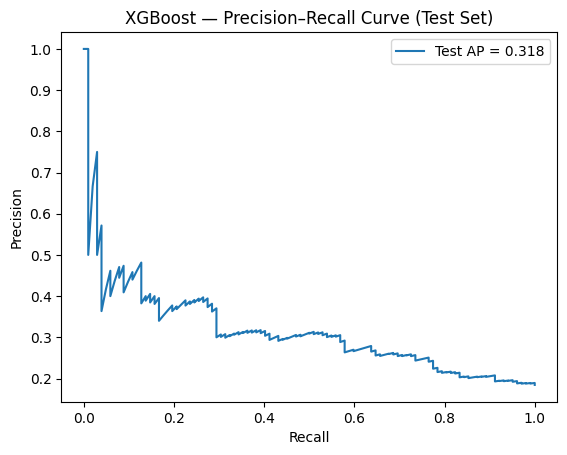

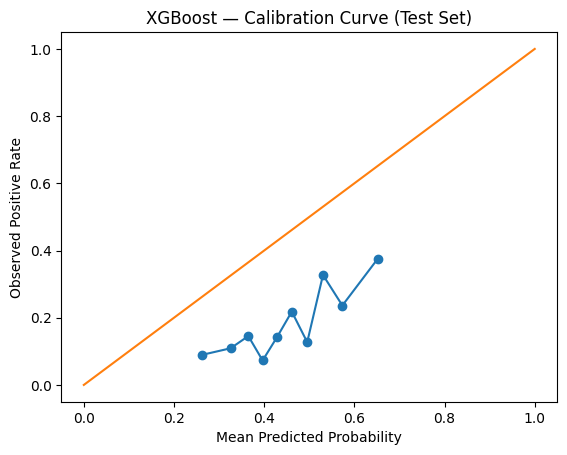

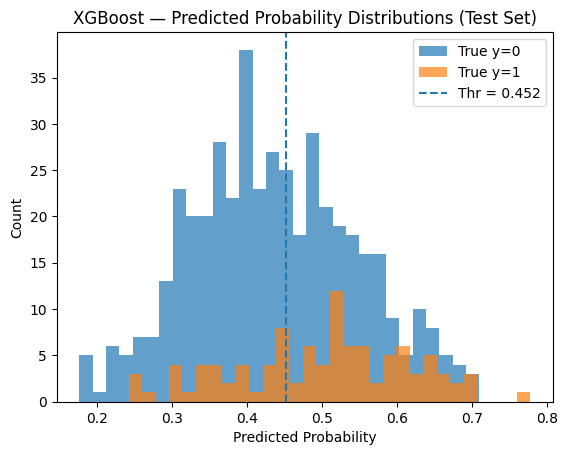


Best XGBoost estimator:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=1,
              max_depth=3, max_leaves=None, min_child_weight=12, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)


In [59]:
# ============================================================
# XGBOOST — TUNING (CV=3) + YOUDEN (CORRECT: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (COLORED CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 0) COPIES + IMBALANCE RATIO
# ----------------------------
X_train2 = X_train.copy()
X_test2  = X_test.copy()

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos = neg / pos

RANDOM_STATE = 42
cv_tune   = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----------------------------
# 1) BASE MODEL
# ----------------------------
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",          # stable for training; AUC used in CV scoring
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=scale_pos
)

# ----------------------------
# 2) TUNING SPACE (your grid + useful additions)
#    Additions:
#    - reg_lambda & reg_alpha already included (good)
#    - min_child_weight already included (good)
#    - max_delta_step sometimes stabilizes imbalanced logistic loss (optional)
# ----------------------------
param_dist_xgb = {
    "n_estimators": [300, 500, 800, 1200, 1600],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 8, 12],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_lambda": [0.5, 1, 2, 5, 10],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "max_delta_step": [0, 1, 5]     # optional stabilizer for imbalance
}

rs_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=40,
    scoring="roc_auc",
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running XGBoost RandomizedSearchCV...")
rs_xgb.fit(X_train2, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs_xgb.best_score_, 4))
print("Best Parameters (XGBoost):")
print(rs_xgb.best_params_)

best_xgb = rs_xgb.best_estimator_  # refit=True by default


# ----------------------------
# 3) YOUDEN THRESHOLD (CORRECT WAY): TRAIN ONLY, CV=5 OOF PROBS
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

oof_prob = cross_val_predict(
    best_xgb,
    X_train2, y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_thr, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_thr, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))


# ----------------------------
# 4) FINAL MODEL FIT ON FULL TRAIN + SINGLE TEST EVALUATION
# ----------------------------
best_xgb.fit(X_train2, y_train)

y_prob_test = best_xgb.predict_proba(X_test2)[:, 1]
y_pred_test = (y_prob_test >= youden_thr).astype(int)

test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("XGBOOST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {test_auc:.4f}")
print(f"Test PR–AUC : {test_ap:.4f}")
print(f"Threshold used (Youden, from train OOF): {youden_thr:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)

# Summary table (handy for thesis)
summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs_xgb.best_score_,
        youden_thr,
        youden_j_best,
        test_auc,
        test_ap,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(summary)


# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 COLORED CONFUSION MATRIX (Matplotlib colormap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"XGBoost — Confusion Matrix (thr={youden_thr:.3f})")
plt.show()

# 5.2 ROC CURVE (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 PRECISION–RECALL CURVE (TEST)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"Test AP = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 CALIBRATION CURVE (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("XGBoost — Calibration Curve (Test Set)")
plt.show()

# 5.5 PROBABILITY DISTRIBUTIONS (TEST) + THRESHOLD
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(youden_thr, linestyle="--", label=f"Thr = {youden_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("XGBoost — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

print("\nBest XGBoost estimator:")
print(best_xgb)


## cutoff 3

In [60]:
df2 = df2[df2["DaysMarijuanaPast12M_W4"].notna()].copy()
df2["heavy_smoker"] = (df2["DaysMarijuanaPast12M_W4"] >3 ).astype(int)

y = df2["heavy_smoker"]

X = df2.drop(columns=["DaysMarijuanaPast12M_W4", "heavy_smoker"])

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [62]:
X_train2=X_train.copy()
X_test2=X_test.copy()

## RandomForest

Running RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.6315
Best Parameters:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 10, 'min_impurity_decrease': 0.0, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None, 'bootstrap': False}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.254
Youden J (train OOF): 0.1913
Sensitivity (TPR) @ thr: 0.5678
Specificity (TNR) @ thr: 0.6235

RANDOM FOREST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.6701
Test PR–AUC : 0.4021
Threshold used (Youden, from train OOF): 0.2540

Accuracy : 0.6257
Precision: 0.3458
Recall   : 0.6241
F1-score : 0.4450

Confusion Matrix (Test):
 [[263 157]
 [ 50  83]] 

Classification Report (Test):
              precision    recall  f1-score     support
0              0.840256  0.626190  0.717599  420.000000
1              0.345833  0.624060  0.445040  133.000000
accuracy       0.625678  0.625678  0.625678    0.6

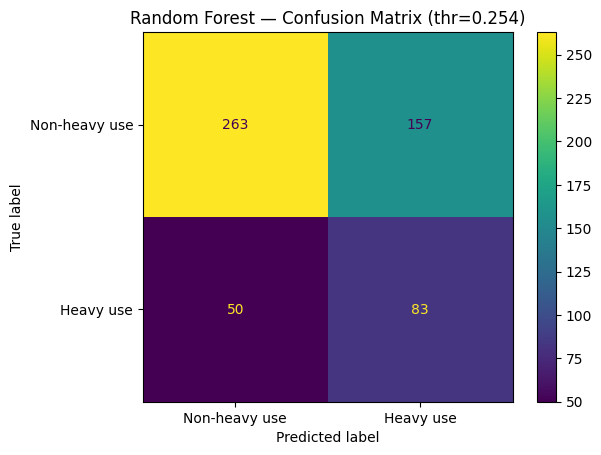

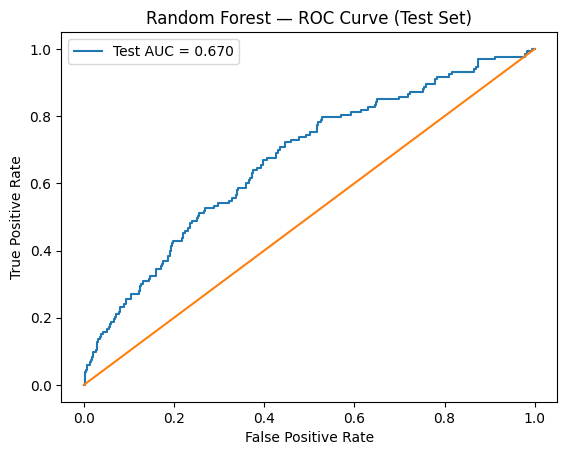

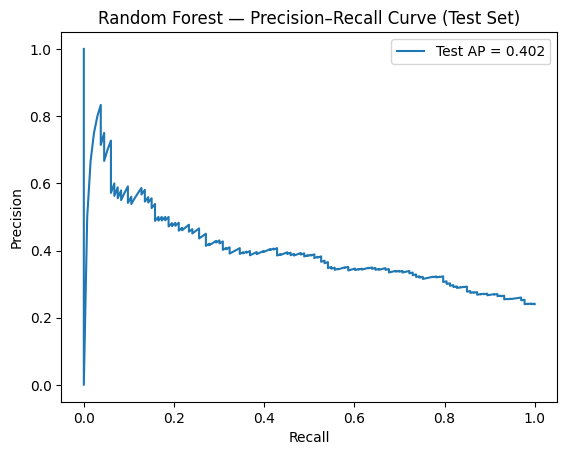

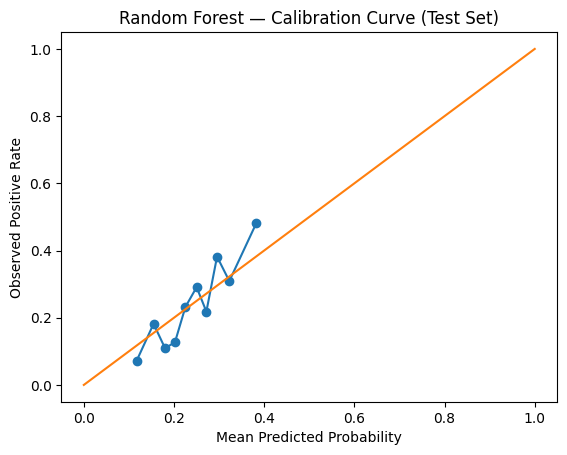

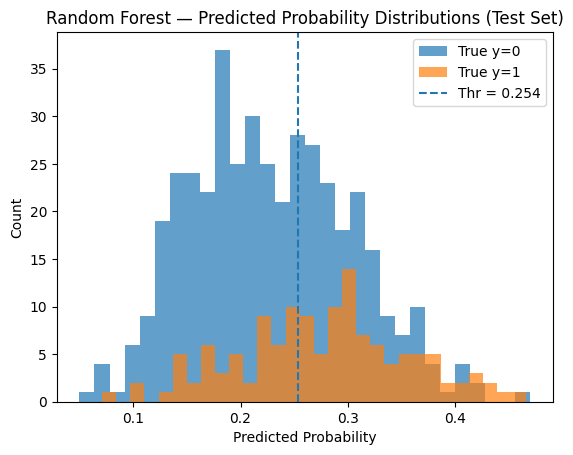


Best RF estimator:
RandomForestClassifier(bootstrap=False, max_depth=10, max_features='log2',
                       min_samples_leaf=10, min_samples_split=10,
                       n_estimators=500, n_jobs=-1, random_state=42)


In [63]:
# ============================================================
# RANDOM FOREST — TUNING (CV=3) + YOUDEN (CORRECT: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (COLORED CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 0) SETTINGS
# ----------------------------
RANDOM_STATE = 42

# Tuning CV (your preference)
cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Youden threshold CV (train-only, more stable)
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----------------------------
# 1) BASE MODEL
# ----------------------------
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# ----------------------------
# 2) TUNING SPACE (your grid + a couple of useful additions)
#    Additions:
#    - bootstrap: can affect calibration/variance
#    - min_impurity_decrease: small regularization knob (optional)
# ----------------------------
param_dist = {
    'n_estimators': [300, 500, 800, 1200, 1600],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6, 10],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.8, None],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'bootstrap': [True, False],
    'min_impurity_decrease': [0.0, 0.0001, 0.001]
}

rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running RandomizedSearchCV...")
rs.fit(X_train2, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs.best_score_, 4))
print("Best Parameters:")
print(rs.best_params_)

best_rf = rs.best_estimator_  # best hyperparameters (refit=True by default)

# ----------------------------
# 3) YOUDEN THRESHOLD (CORRECT WAY)
#    - compute OOF probabilities on TRAIN ONLY using CV=5
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

oof_prob = cross_val_predict(
    best_rf,
    X_train2, y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_thr, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_thr, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))

# ----------------------------
# 4) FINAL MODEL FIT ON FULL TRAIN + SINGLE TEST EVALUATION
# ----------------------------
best_rf.fit(X_train2, y_train)

y_prob_test = best_rf.predict_proba(X_test2)[:, 1]
y_pred_test = (y_prob_test >= youden_thr).astype(int)

test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("RANDOM FOREST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {test_auc:.4f}")
print(f"Test PR–AUC : {test_ap:.4f}")
print(f"Threshold used (Youden, from train OOF): {youden_thr:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)

# Summary table (handy for thesis)
summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs.best_score_,
        youden_thr,
        youden_j_best,
        test_auc,
        test_ap,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(summary)

# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 COLORED CONFUSION MATRIX (Matplotlib colormap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"Random Forest — Confusion Matrix (thr={youden_thr:.3f})")
plt.show()

# 5.2 ROC CURVE (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 PRECISION–RECALL CURVE (TEST)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"Test AP = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 CALIBRATION CURVE (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Random Forest — Calibration Curve (Test Set)")
plt.show()

# 5.5 PROBABILITY DISTRIBUTIONS (TEST) + THRESHOLD
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(youden_thr, linestyle="--", label=f"Thr = {youden_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Random Forest — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

print("\nBest RF estimator:")
print(best_rf)


## CatBoost

Running CatBoost RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.6351
Best Parameters (CatBoost):
{'subsample': 0.9, 'rsm': 0.6, 'random_strength': 10, 'learning_rate': 0.01, 'l2_leaf_reg': 7, 'iterations': 400, 'depth': 4, 'class_weights': [1, 5], 'bagging_temperature': 0}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.5886
Youden J (train OOF): 0.2117
Sensitivity (TPR) @ thr: 0.6382
Specificity (TNR) @ thr: 0.5735

CATBOOST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.6772
Test PR–AUC : 0.4049
Threshold used (Youden, from train OOF): 0.5886

Accuracy : 0.6130
Precision: 0.3506
Recall   : 0.7143
F1-score : 0.4703

Confusion Matrix (Test):
 [[244 176]
 [ 38  95]] 

Classification Report (Test):
              precision    recall  f1-score    support
0              0.865248  0.580952  0.695157  420.00000
1              0.350554  0.714286  0.470297  133.00000
accuracy       0.613020  0.613020  0.613020 

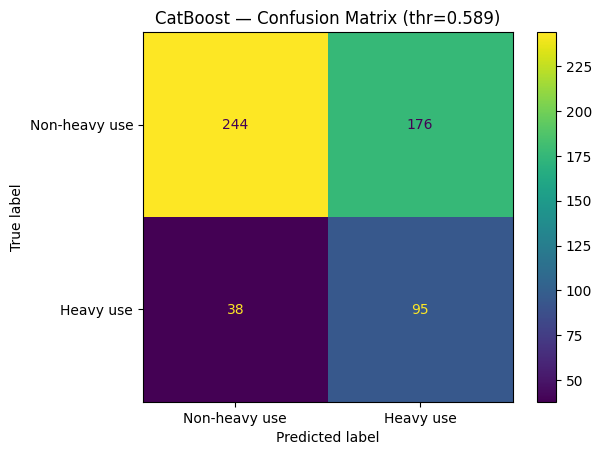

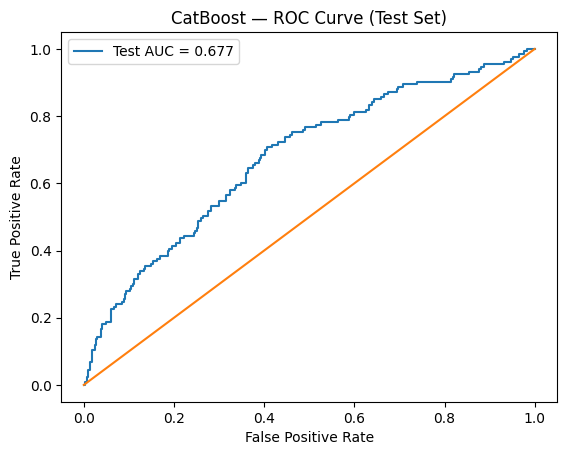

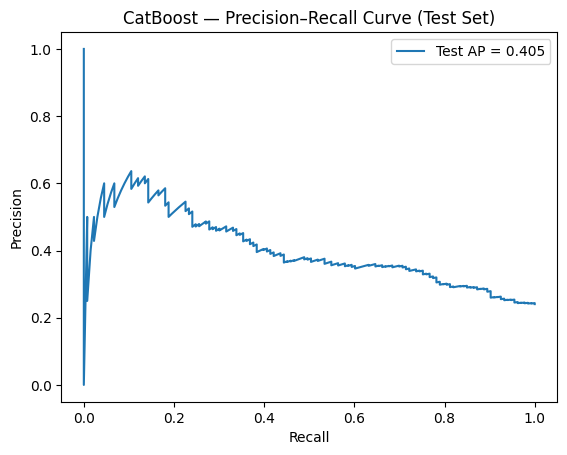

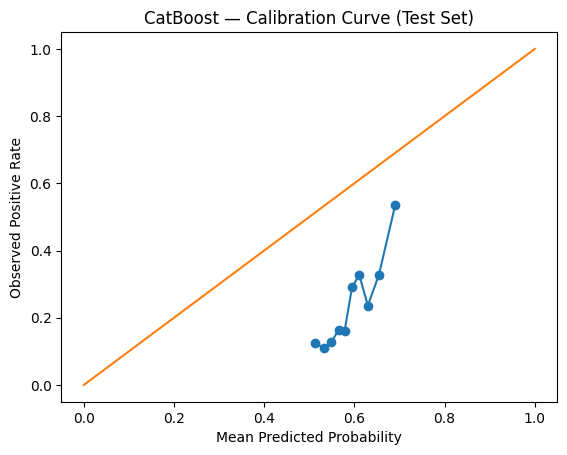

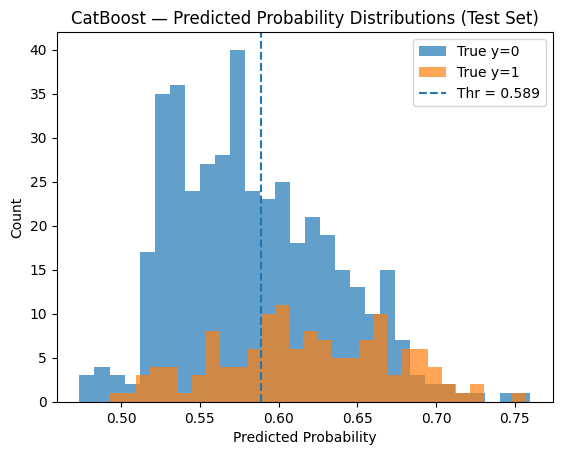


Best CatBoost estimator:


In [64]:
# ============================================================
# CATBOOST — TUNING (CV=3) + YOUDEN (CORRECT: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (COLORED CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 0) SETTINGS
# ----------------------------
RANDOM_STATE = 42

cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # tuning CV
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) # threshold CV

# ----------------------------
# 1) BASE MODEL
# ----------------------------
cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)

# ----------------------------
# 2) TUNING SPACE
#    Your grid + a couple of useful additions for generalization:
#    - rsm (feature subsampling) helps reduce overfit
#    - bagging_temperature controls bootstrap strength (esp. good for CatBoost)
# ----------------------------
param_dist_cat = {
    "iterations": [400, 800, 1200, 1600],
    "depth": [4, 5, 6, 7, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9, 12, 15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "random_strength": [0, 1, 2, 5, 10],
    "bagging_temperature": [0, 1, 5, 10],
    "rsm": [0.6, 0.8, 1.0],
    # your class-weights tuning (fine)
    "class_weights": [[1, 3], [1, 5], [1, 7], [1, 10]]
}

rs_cat = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist_cat,
    n_iter=40,
    scoring="roc_auc",
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running CatBoost RandomizedSearchCV...")
rs_cat.fit(X_train2, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs_cat.best_score_, 4))
print("Best Parameters (CatBoost):")
print(rs_cat.best_params_)

best_cat = rs_cat.best_estimator_  # refit=True by default


# ----------------------------
# 3) YOUDEN THRESHOLD (CORRECT WAY): TRAIN ONLY, CV=5 OOF PROBS
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

oof_prob = cross_val_predict(
    best_cat,
    X_train2, y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_thr, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_thr, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))


# ----------------------------
# 4) FINAL MODEL FIT ON FULL TRAIN + SINGLE TEST EVALUATION
# ----------------------------
best_cat.fit(X_train2, y_train)

y_prob_test = best_cat.predict_proba(X_test2)[:, 1]
y_pred_test = (y_prob_test >= youden_thr).astype(int)

test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("CATBOOST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {test_auc:.4f}")
print(f"Test PR–AUC : {test_ap:.4f}")
print(f"Threshold used (Youden, from train OOF): {youden_thr:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)

# Summary table (handy for thesis)
summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs_cat.best_score_,
        youden_thr,
        youden_j_best,
        test_auc,
        test_ap,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(summary)


# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 COLORED CONFUSION MATRIX (Matplotlib colormap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"CatBoost — Confusion Matrix (thr={youden_thr:.3f})")
plt.show()

# 5.2 ROC CURVE (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CatBoost — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 PRECISION–RECALL CURVE (TEST)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"Test AP = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CatBoost — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 CALIBRATION CURVE (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("CatBoost — Calibration Curve (Test Set)")
plt.show()

# 5.5 PROBABILITY DISTRIBUTIONS (TEST) + THRESHOLD
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(youden_thr, linestyle="--", label=f"Thr = {youden_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("CatBoost — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

print("\nBest CatBoost estimator:")
print(best_cat)


## XGBoost

Running XGBoost RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.6143
Best Parameters (XGBoost):
{'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 4, 'max_delta_step': 5, 'learning_rate': 0.1, 'gamma': 5, 'colsample_bytree': 0.7}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.4337
Youden J (train OOF): 0.1468
Sensitivity (TPR) @ thr: 0.6432
Specificity (TNR) @ thr: 0.5036

XGBOOST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.6359
Test PR–AUC : 0.3538
Threshold used (Youden, from train OOF): 0.4337

Accuracy : 0.5407
Precision: 0.3055
Recall   : 0.7143
F1-score : 0.4279

Confusion Matrix (Test):
 [[204 216]
 [ 38  95]] 

Classification Report (Test):
              precision    recall  f1-score     support
0              0.842975  0.485714  0.616314  420.000000
1              0.305466  0.714286  0.427928  133.000000
accuracy       0.540687  0.54

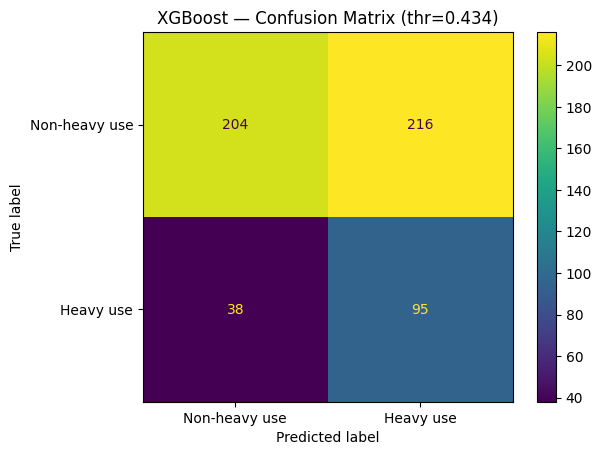

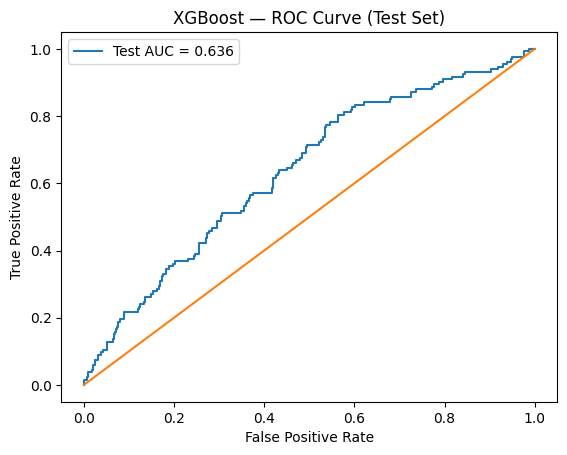

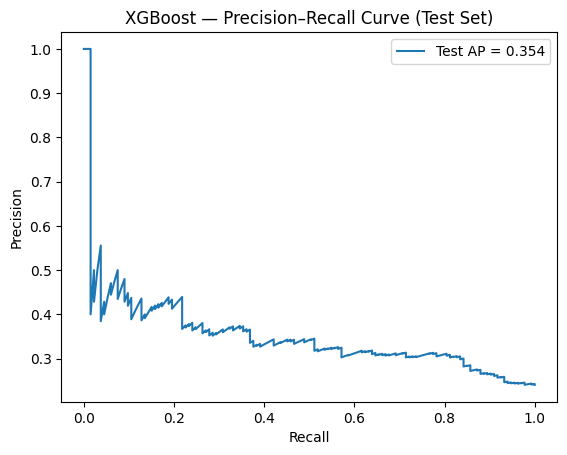

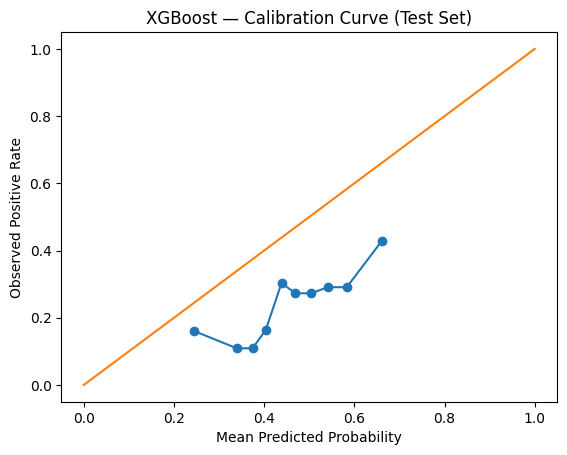

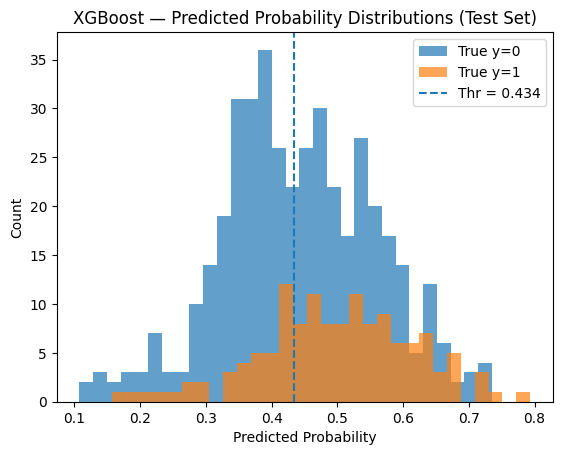


Best XGBoost estimator:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=5,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=5,
              max_depth=4, max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)


In [65]:
# ============================================================
# XGBOOST — TUNING (CV=3) + YOUDEN (CORRECT: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (COLORED CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 0) COPIES + IMBALANCE RATIO
# ----------------------------
X_train2 = X_train.copy()
X_test2  = X_test.copy()

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos = neg / pos

RANDOM_STATE = 42
cv_tune   = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----------------------------
# 1) BASE MODEL
# ----------------------------
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",          # stable for training; AUC used in CV scoring
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=scale_pos
)

# ----------------------------
# 2) TUNING SPACE (your grid + useful additions)
#    Additions:
#    - reg_lambda & reg_alpha already included (good)
#    - min_child_weight already included (good)
#    - max_delta_step sometimes stabilizes imbalanced logistic loss (optional)
# ----------------------------
param_dist_xgb = {
    "n_estimators": [300, 500, 800, 1200, 1600],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 8, 12],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_lambda": [0.5, 1, 2, 5, 10],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "max_delta_step": [0, 1, 5]     # optional stabilizer for imbalance
}

rs_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=40,
    scoring="roc_auc",
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running XGBoost RandomizedSearchCV...")
rs_xgb.fit(X_train2, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs_xgb.best_score_, 4))
print("Best Parameters (XGBoost):")
print(rs_xgb.best_params_)

best_xgb = rs_xgb.best_estimator_  # refit=True by default


# ----------------------------
# 3) YOUDEN THRESHOLD (CORRECT WAY): TRAIN ONLY, CV=5 OOF PROBS
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

oof_prob = cross_val_predict(
    best_xgb,
    X_train2, y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_thr, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_thr, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))


# ----------------------------
# 4) FINAL MODEL FIT ON FULL TRAIN + SINGLE TEST EVALUATION
# ----------------------------
best_xgb.fit(X_train2, y_train)

y_prob_test = best_xgb.predict_proba(X_test2)[:, 1]
y_pred_test = (y_prob_test >= youden_thr).astype(int)

test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("XGBOOST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {test_auc:.4f}")
print(f"Test PR–AUC : {test_ap:.4f}")
print(f"Threshold used (Youden, from train OOF): {youden_thr:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)

# Summary table (handy for thesis)
summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs_xgb.best_score_,
        youden_thr,
        youden_j_best,
        test_auc,
        test_ap,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(summary)


# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 COLORED CONFUSION MATRIX (Matplotlib colormap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"XGBoost — Confusion Matrix (thr={youden_thr:.3f})")
plt.show()

# 5.2 ROC CURVE (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 PRECISION–RECALL CURVE (TEST)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"Test AP = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 CALIBRATION CURVE (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("XGBoost — Calibration Curve (Test Set)")
plt.show()

# 5.5 PROBABILITY DISTRIBUTIONS (TEST) + THRESHOLD
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(youden_thr, linestyle="--", label=f"Thr = {youden_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("XGBoost — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

print("\nBest XGBoost estimator:")
print(best_xgb)


## Plain Logistic Cutoff 4

In [66]:
df_logit=pd.read_csv('W1-4_fulldata_filtered.csv')

In [67]:
df_logit=df_logit.drop(columns=['TotalDrinking'],errors='ignore')

In [68]:
df_logit = df_logit[df_logit['DaysMarijuanaPast12M_W4'].notna()]

In [69]:
df_logit=df2.copy()
keep = {
    "GPA_Index",
    "ParentalWarmth_Index",
    "ParentalSupervision_Index",
    "SportsParticipation_Index"
}

cols_to_drop = [
    col for col in df2.columns
    if "index" in col.lower() and col not in keep
]

df_logit = df_logit.drop(columns=cols_to_drop)


In [70]:
import numpy as np
import pandas as pd

# =========================
# USER SETTINGS
# =========================
target = "DaysMarijuanaPast12M_W4"  
corr_thr = 0.04                      # sensible given weak correlations
pair_corr_cut = 0.80                 # multicollinearity screen

# =========================
# 0) Basic numeric-only frame + drop rows missing target
# =========================
df = df_logit.copy()

# Keep numeric predictors only (bool allowed)
numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()

if target not in df.columns:
    raise ValueError(f"Target '{target}' not found in df_all.")

# Ensure target is numeric
if not np.issubdtype(df[target].dtype, np.number):
    df[target] = pd.to_numeric(df[target], errors="coerce")

df = df.dropna(subset=[target])

# Candidate predictors
X_cols_all = [c for c in numeric_cols if c != target]

# Drop near-zero variance columns
low_var = [c for c in X_cols_all if df[c].nunique(dropna=True) <= 1]
X_cols_all = [c for c in X_cols_all if c not in low_var]

# =========================
# 1) Filter by correlation with target
# =========================
corrs = df[X_cols_all + [target]].corr(numeric_only=True)[target].drop(target)
corrs_abs = corrs.abs().sort_values(ascending=False)

corr_keep = corrs_abs[corrs_abs >= corr_thr].index.tolist()

# Relax threshold if too few survive
if len(corr_keep) < 10 and len(corrs_abs) > 0:
    corr_thr_relaxed = max(0.01, corr_thr / 2)
    corr_keep = corrs_abs[corrs_abs >= corr_thr_relaxed].index.tolist()
    print(f"[Info] Relaxed corr threshold to {corr_thr_relaxed:.3f}")
else:
    corr_thr_relaxed = corr_thr

print(f"[Step 1] Kept {len(corr_keep)} vars with |corr| ≥ {corr_thr_relaxed:.3f}")

# =========================
# 2) Remove multicollinearity by pairwise correlation
#    (drop weaker-to-target variable)
# =========================
X_corr = df[corr_keep].corr().abs()

to_drop = set()
cols = X_corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if X_corr.loc[c1, c2] >= pair_corr_cut:
            # drop the weaker variable (lower |corr with target|)
            if corrs_abs[c1] >= corrs_abs[c2]:
                to_drop.add(c2)
            else:
                to_drop.add(c1)

pairwise_keep = [c for c in corr_keep if c not in to_drop]

print(f"[Step 2] Dropped {len(to_drop)} vars with pairwise |corr| ≥ {pair_corr_cut:.2f}")
print(f"[Step 2] Remaining vars: {len(pairwise_keep)}")

# =========================
# 3) Outputs
# =========================
vars_decent_corr = corr_keep
vars_low_multicollinearity = pairwise_keep

print("\n=== FINAL FEATURE SET ===")
print(f"Variables kept (n={len(vars_low_multicollinearity)}):")
for v in vars_low_multicollinearity:
    print(v)


# =========================
# 4) Filtered dataframe (NO imputation)
# =========================
df_logit = df[vars_low_multicollinearity + [target]].copy()


[Step 1] Kept 61 vars with |corr| ≥ 0.040
[Step 2] Dropped 0 vars with pairwise |corr| ≥ 0.80
[Step 2] Remaining vars: 61

=== FINAL FEATURE SET ===
Variables kept (n=61):
heavy_smoker
Trouble_GetAlong_Teachers_W1
Sex_Female
GPA_Index
FriendsRespect_Sex
Age_FirstMarijuana
Lifetime_Marijuana
PhysicalFight_W1
SoldDrugs_Z
SawViolentAttack_W1
Fight_Serious_Z
NightAway_W1
Rev_UpsetMother_Sex_Z
ClosenessToMother_W1
WeaponThreat_W1
PeerWeed_Count
NotWorthLiving
Relax_Sex
Age_FirstCocaine
TeacherCare_W1
SchoolExpulsion
FriendCare_W1
DrugsAvailable_Home
LessLonely_Sex
GroupFight_Z
BuildingCondition
DroveWithoutPermission_Z
Age_FirstDrinkNoAdults
ExpectCollege_W1
Bills_Payment_Ability
PeerCig_Count
Age at First Drink
DrinksPerOccasion_Past12mo
StreetCondition
Attractive_Sex
HoursGames_W1
Trouble Paying Attention
Mother_Education
HoursTV_W1
InjuredSomeone
TroubleGetAlong_Students_W1
ParentCare_W1
Rev_FeelGuilty_Sex_Z
Household_Income
ParentalSupervision_Index
NeighborhoodType_6
AdultCare_W1
Suici

In [71]:
df_logit = df_logit[df_logit["DaysMarijuanaPast12M_W4"].notna()].copy()
df_logit["heavy_smoker"] = (df_logit["DaysMarijuanaPast12M_W4"] >4 ).astype(int)

y = df_logit["heavy_smoker"]

X = df_logit.drop(columns=["DaysMarijuanaPast12M_W4", "heavy_smoker"])

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [73]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import statsmodels.api as sm

# --- 1) TRAIN medians (store them)
train_medians = X_train.median(numeric_only=True)

# --- 2) Impute using TRAIN medians for both train and test
X_train_imp = X_train.fillna(train_medians)
X_test_imp  = X_test.fillna(train_medians)

# --- 3) Scale using TRAIN statistics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Keep names for statsmodels
feature_names = X_train.columns.tolist()


In [74]:
from sklearn.linear_model import LogisticRegression
lr_plain = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000)
lr_plain.fit(X_train_scaled, y_train)

y_pred_prob = lr_plain.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

y_pred_class = (y_pred_prob >= best_threshold).astype(int)

print("AUC:", roc_auc_score(y_test, y_pred_prob))
print("Optimal threshold (Youden J):", round(best_threshold, 4))
print("\nClassification report:\n", classification_report(y_test, y_pred_class))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_class))


AUC: 0.6659275683665928
Optimal threshold (Youden J): 0.1703

Classification report:
               precision    recall  f1-score   support

           0       0.89      0.65      0.75       451
           1       0.30      0.66      0.41       102

    accuracy                           0.65       553
   macro avg       0.59      0.65      0.58       553
weighted avg       0.78      0.65      0.69       553


Confusion matrix:
 [[291 160]
 [ 35  67]]


In [75]:
# Build a DataFrame so statsmodels keeps names
X_train_sm = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_train_sm = sm.add_constant(X_train_sm, has_constant="add")

logit_model = sm.Logit(y_train.astype(float), X_train_sm.astype(float))
logit_result = logit_model.fit(method="lbfgs", disp=False)

# Results table
results_table = pd.DataFrame({
    "Variable": X_train_sm.columns,
    "Coefficient": logit_result.params,
    "Std_Error": logit_result.bse,
    "p_value": logit_result.pvalues
})

results_table["Odds_Ratio"] = np.exp(results_table["Coefficient"])
# Confidence intervals (log-odds scale)
conf = logit_result.conf_int()
conf.columns = ["CI_lower", "CI_upper"]

# Add CI to table
results_table["CI_lower"] = conf["CI_lower"].values
results_table["CI_upper"] = conf["CI_upper"].values

# Odds ratio confidence intervals
results_table["OR_CI_lower"] = np.exp(results_table["CI_lower"])
results_table["OR_CI_upper"] = np.exp(results_table["CI_upper"])
results_table = results_table[results_table["Variable"] != "const"].sort_values("p_value")

results_table


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio,CI_lower,CI_upper,OR_CI_lower,OR_CI_upper
DrinkWithoutAdults_Z,DrinkWithoutAdults_Z,-0.162045,0.063079,0.010201,0.850403,-0.285677,-0.038414,0.751505,0.962315
ClosenessToMother_W1,ClosenessToMother_W1,-0.147381,0.059552,0.013330,0.862965,-0.264101,-0.030661,0.767896,0.969804
GroupFight_Z,GroupFight_Z,-0.200419,0.081872,0.014367,0.818388,-0.360886,-0.039952,0.697058,0.960835
Sex_Female,Sex_Female,-0.170037,0.081086,0.035994,0.843634,-0.328962,-0.011111,0.719670,0.988950
NotWorthLiving,NotWorthLiving,0.137149,0.068039,0.043826,1.146999,0.003796,0.270503,1.003803,1.310623
Trouble_HomeworkCompletion_W1,Trouble_HomeworkCompletion_W1,-0.168549,0.087399,0.053794,0.844890,-0.339848,0.002751,0.711878,1.002755
ExpectCollege_W1,ExpectCollege_W1,0.151564,0.079595,0.056886,1.163653,-0.004440,0.307568,0.995570,1.360113
FriendsRespect_Sex,FriendsRespect_Sex,0.146159,0.077329,0.058746,1.157380,-0.005403,0.297721,0.994611,1.346786
GPA_Index,GPA_Index,-0.145101,0.081638,0.075509,0.864935,-0.305109,0.014907,0.737043,1.015019
Rev_UpsetMother_Sex_Z,Rev_UpsetMother_Sex_Z,0.133779,0.075843,0.077748,1.143141,-0.014870,0.282428,0.985240,1.326347


In [76]:
alpha = 0.05

significant_vars = results_table[
    results_table["p_value"] < alpha
].copy()

significant_vars


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio,CI_lower,CI_upper,OR_CI_lower,OR_CI_upper
DrinkWithoutAdults_Z,DrinkWithoutAdults_Z,-0.162045,0.063079,0.010201,0.850403,-0.285677,-0.038414,0.751505,0.962315
ClosenessToMother_W1,ClosenessToMother_W1,-0.147381,0.059552,0.013330,0.862965,-0.264101,-0.030661,0.767896,0.969804
GroupFight_Z,GroupFight_Z,-0.200419,0.081872,0.014367,0.818388,-0.360886,-0.039952,0.697058,0.960835
Sex_Female,Sex_Female,-0.170037,0.081086,0.035994,0.843634,-0.328962,-0.011111,0.719670,0.988950
NotWorthLiving,NotWorthLiving,0.137149,0.068039,0.043826,1.146999,0.003796,0.270503,1.003803,1.310623


## Cutoff 3

In [77]:
df_logit = df_logit[df_logit["DaysMarijuanaPast12M_W4"].notna()].copy()
df_logit["heavy_smoker"] = (df_logit["DaysMarijuanaPast12M_W4"] >3 ).astype(int)

y = df_logit["heavy_smoker"]

X = df_logit.drop(columns=["DaysMarijuanaPast12M_W4", "heavy_smoker"])

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [79]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import statsmodels.api as sm

# --- 1) TRAIN medians (store them)
train_medians = X_train.median(numeric_only=True)

# --- 2) Impute using TRAIN medians for both train and test
X_train_imp = X_train.fillna(train_medians)
X_test_imp  = X_test.fillna(train_medians)

# --- 3) Scale using TRAIN statistics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Keep names for statsmodels
feature_names = X_train.columns.tolist()


In [80]:
from sklearn.linear_model import LogisticRegression
lr_plain = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000)
lr_plain.fit(X_train_scaled, y_train)

y_pred_prob = lr_plain.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

y_pred_class = (y_pred_prob >= best_threshold).astype(int)

print("AUC:", roc_auc_score(y_test, y_pred_prob))
print("Optimal threshold (Youden J):", round(best_threshold, 4))
print("\nClassification report:\n", classification_report(y_test, y_pred_class))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_class))


AUC: 0.6431435732187611
Optimal threshold (Youden J): 0.228

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.56      0.67       420
           1       0.33      0.68      0.44       133

    accuracy                           0.59       553
   macro avg       0.59      0.62      0.56       553
weighted avg       0.72      0.59      0.62       553


Confusion matrix:
 [[235 185]
 [ 43  90]]


In [81]:
# Build a DataFrame so statsmodels keeps names
X_train_sm = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_train_sm = sm.add_constant(X_train_sm, has_constant="add")

logit_model = sm.Logit(y_train.astype(float), X_train_sm.astype(float))
logit_result = logit_model.fit(method="lbfgs", disp=False)

# Results table
results_table = pd.DataFrame({
    "Variable": X_train_sm.columns,
    "Coefficient": logit_result.params,
    "Std_Error": logit_result.bse,
    "p_value": logit_result.pvalues
})

results_table["Odds_Ratio"] = np.exp(results_table["Coefficient"])
# Confidence intervals (log-odds scale)
conf = logit_result.conf_int()
conf.columns = ["CI_lower", "CI_upper"]

# Add CI to table
results_table["CI_lower"] = conf["CI_lower"].values
results_table["CI_upper"] = conf["CI_upper"].values

# Odds ratio confidence intervals
results_table["OR_CI_lower"] = np.exp(results_table["CI_lower"])
results_table["OR_CI_upper"] = np.exp(results_table["CI_upper"])
results_table = results_table[results_table["Variable"] != "const"].sort_values("p_value")

results_table


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio,CI_lower,CI_upper,OR_CI_lower,OR_CI_upper
Sex_Female,Sex_Female,-0.274918,0.073031,0.000167,0.759634,-0.418057,-0.131779,0.658325,0.876535
DrinkWithoutAdults_Z,DrinkWithoutAdults_Z,-0.138215,0.058390,0.017927,0.870911,-0.252657,-0.023774,0.776734,0.976507
WorkedForPay_W1,WorkedForPay_W1,-0.135653,0.062683,0.030455,0.873146,-0.258509,-0.012797,0.772202,0.987284
DrugsAvailable_Home,DrugsAvailable_Home,0.116023,0.055878,0.037861,1.123021,0.006504,0.225541,1.006525,1.253001
ParentalSupervision_Index,ParentalSupervision_Index,0.129107,0.063614,0.042404,1.137812,0.004425,0.253788,1.004435,1.288899
FriendCare_W1,FriendCare_W1,-0.124276,0.063955,0.051995,0.883136,-0.249626,0.001074,0.779092,1.001074
Household_Income,Household_Income,-0.193296,0.101730,0.057423,0.824238,-0.392684,0.006093,0.675242,1.006111
NeighborhoodType_6,NeighborhoodType_6,-0.199949,0.107610,0.063155,0.818772,-0.410861,0.010962,0.663079,1.011022
Rev_UpsetMother_Sex_Z,Rev_UpsetMother_Sex_Z,0.116774,0.068302,0.087325,1.123866,-0.017095,0.250643,0.983051,1.284852
ExpectCollege_W1,ExpectCollege_W1,0.123795,0.072516,0.087797,1.131784,-0.018334,0.265924,0.981833,1.304636


In [82]:
alpha = 0.05

significant_vars = results_table[
    results_table["p_value"] < alpha
].copy()

significant_vars


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio,CI_lower,CI_upper,OR_CI_lower,OR_CI_upper
Sex_Female,Sex_Female,-0.274918,0.073031,0.000167,0.759634,-0.418057,-0.131779,0.658325,0.876535
DrinkWithoutAdults_Z,DrinkWithoutAdults_Z,-0.138215,0.058390,0.017927,0.870911,-0.252657,-0.023774,0.776734,0.976507
WorkedForPay_W1,WorkedForPay_W1,-0.135653,0.062683,0.030455,0.873146,-0.258509,-0.012797,0.772202,0.987284
DrugsAvailable_Home,DrugsAvailable_Home,0.116023,0.055878,0.037861,1.123021,0.006504,0.225541,1.006525,1.253001
ParentalSupervision_Index,ParentalSupervision_Index,0.129107,0.063614,0.042404,1.137812,0.004425,0.253788,1.004435,1.288899
